## Problem 1

In [1]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate random matrix A and vector b
A = np.random.randn(50, 10)
b = np.random.randn(50)


In [3]:
def steepest_descent(A, b, x0, step_size_func, max_iter=1000, tol=1e-6):
    x = x0
    obj_values = []
    
    for r in range(1, max_iter + 1):
        grad = A.T @ (A @ x - b)
        obj_values.append(0.5 * np.linalg.norm(A @ x - b) ** 2)
        
        # Stop if gradient norm is below tolerance
        if np.linalg.norm(grad) < tol:
            break
        
        # Get step size based on current iteration (r)
        alpha = step_size_func(r)
        
        # Update x
        x = x - alpha * grad
        
    return x, obj_values


In [115]:
def constant_step_size(r):
    return 0.05
    
def diminishing_step_size(r):
    return 0.05 / r

def diminishing_step_size_squared(r):
    return 0.05 / (r ** 2)

def diminishing_step_size_sqrt(r):
    return 0.05 / np.sqrt(r)


In [117]:
def armijo_step_size(A, b, x, grad, beta=0.5, sigma=0.1):
    alpha = 0.05
    while 0.5 * np.linalg.norm(A @ (x - alpha * grad) - b) ** 2 > \
          0.5 * np.linalg.norm(A @ x - b) ** 2 - sigma * alpha * np.linalg.norm(grad) ** 2:
        alpha *= beta
    return alpha


In [119]:
# Initial guess
x0 = np.zeros(10)

# Try constant step size
x_const, obj_values_const = steepest_descent(A, b, x0, constant_step_size)

# Try diminishing step sizes
x_diminish, obj_values_diminish = steepest_descent(A, b, x0, diminishing_step_size)
x_diminish_sq, obj_values_diminish_sq = steepest_descent(A, b, x0, diminishing_step_size_squared)
x_diminish_sqrt, obj_values_diminish_sqrt = steepest_descent(A, b, x0, diminishing_step_size_sqrt)

# Try Armijo step size
x_armijo, obj_values_armijo = steepest_descent(A, b, x0, lambda r: armijo_step_size(A, b, x0, A.T @ (A @ x0 - b)))


C:\Users\alexo\AppData\Local\Temp\ipykernel_25104\3032142845.py:6: RuntimeWarning: overflow encountered in matmul
  grad = A.T @ (A @ x - b)
C:\Users\alexo\AppData\Local\Temp\ipykernel_25104\3032142845.py:6: RuntimeWarning: invalid value encountered in matmul
  grad = A.T @ (A @ x - b)
C:\Users\alexo\AppData\Local\Temp\ipykernel_25104\3032142845.py:7: RuntimeWarning: invalid value encountered in matmul
  obj_values.append(0.5 * np.linalg.norm(A @ x - b) ** 2)


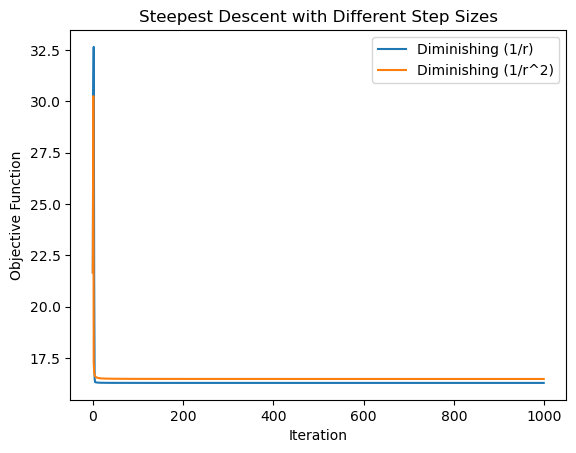

In [127]:
import matplotlib.pyplot as plt

plt.plot(obj_values_const, label='Constant Step Size')
plt.plot(obj_values_diminish, label='Diminishing (1/r)')
plt.plot(obj_values_diminish_sq, label='Diminishing (1/r^2)')
plt.plot(obj_values_diminish_sqrt, label='Diminishing (1/sqrt(r))')
plt.plot(obj_values_armijo, label='Armijo Step Size')
plt.xlabel('Iteration')
plt.ylabel('Objective Function')
plt.legend()
plt.title('Steepest Descent with Different Step Sizes')
plt.show()



## Problem 2

In [159]:
import numpy as np

# Load the dataset
data = np.loadtxt('features_train.txt')

# Separate labels and features
labels = data[:, 0]
features = data[:, 1:3]

# Separate specific digits (e.g., 1 vs 5)
# For example, separating digit '1' and '5'
mask = np.isin(labels, [1, 5])
X = features[mask]
y = labels[mask]

# Filter the dataset to include only labels 1 and 5
mask = np.isin(labels, [1, 5])
X = features[mask]  # Keep only the features corresponding to labels 1 and 5
y = labels[mask]    # Keep only the labels 1 and 5

# Convert labels to binary (-1 for '5' and 1 for '1')
y_binary = np.where(y == 1, 1, -1)

# Convert labels to binary (-1 for '5' and 1 for '1')
y_binary = np.where(y == 1, 1, -1)


In [282]:
def constant_step_size(r):
    return 0.00008 

def diminishing_step_size(r):
    return 0.0002 / r

In [284]:
def armijo_step_size(A, b, x, grad, beta=0.5, sigma=0.1):
    alpha = 0.0001
    while 0.5 * np.linalg.norm(A @ (x - alpha * grad) - b) ** 2 > \
          0.5 * np.linalg.norm(A @ x - b) ** 2 - sigma * alpha * np.linalg.norm(grad) ** 2:
        alpha *= beta
    return alpha



In [286]:
# Initial guess for weights
w0 = np.zeros(X.shape[1])

# Constant step size
w_const, obj_values_const = steepest_descent(X, y_binary, w0, constant_step_size)

# Diminishing step size
w_diminish, obj_values_diminish = steepest_descent(X, y_binary, w0, diminishing_step_size)

# Diminishing (1/r^2) step size
w_diminish_sq, obj_values_diminish_sq = steepest_descent(X, y_binary, w0, diminishing_step_size_squared)

# Diminishing (1/sqrt(r)) step size
w_diminish_sqrt, obj_values_diminish_sqrt = steepest_descent(X, y_binary, w0, diminishing_step_size_sqrt)

# Armijo step size
w_armijo, obj_values_armijo = steepest_descent(X, y_binary, w0, lambda r: armijo_step_size(X, y_binary, w0, X.T @ (X @ w0 - y_binary)))



C:\Users\alexo\AppData\Local\Temp\ipykernel_25104\3032142845.py:6: RuntimeWarning: invalid value encountered in matmul
  grad = A.T @ (A @ x - b)
C:\Users\alexo\AppData\Local\Temp\ipykernel_25104\3032142845.py:17: RuntimeWarning: invalid value encountered in subtract
  x = x - alpha * grad


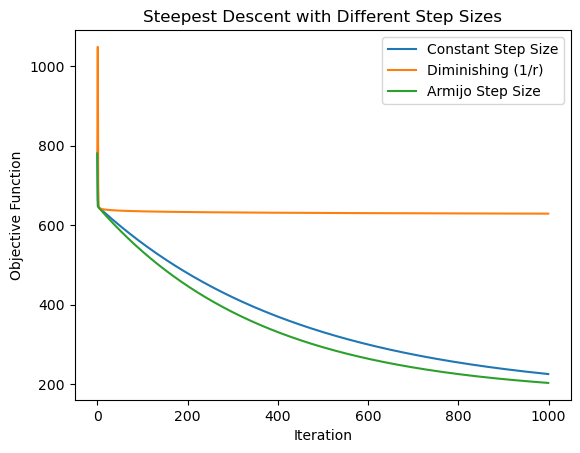

In [287]:
import matplotlib.pyplot as plt

plt.plot(obj_values_const, label='Constant Step Size')
plt.plot(obj_values_diminish, label='Diminishing (1/r)')
plt.plot(obj_values_armijo, label='Armijo Step Size')
plt.xlabel('Iteration')
plt.ylabel('Objective Function')
plt.legend()
plt.title('Steepest Descent with Different Step Sizes')
plt.show()
